## **Customer shopping**

### Contents
1. Load data and check size
2. Drop unused columns
3. Check missing values, duplicates, and dtypes
4. Split by Gender
5. EDA — Item Purchased, Size, Category, Review Rating, Purchase Amount
6. Multivariate — correlation heatmap
7. Feature engineering — dummy variables, scaling, binning
8. Summary

In [1]:
# TODO: import pandas, numpy, matplotlib.pyplot, and seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# TODO: load shopping_trends.csv with pd.read_csv(), then show the first 5 rows
df=pd.read_csv('shopping_trends.csv')

In [ ]:
# TODO: check the dataset size with df.shape
df.shape

TypeError: 'tuple' object is not callable

In [8]:
# TODO: drop the Customer ID column  
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   str    
 3   Item Purchased            3900 non-null   str    
 4   Category                  3900 non-null   str    
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   str    
 7   Size                      3900 non-null   str    
 8   Color                     3900 non-null   str    
 9   Season                    3900 non-null   str    
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   str    
 12  Payment Method            3900 non-null   str    
 13  Shipping Type             3900 non-null   str    
 14  Discount Applied   

In [ ]:
df=df.drop(columns=['Customer ID'])


KeyError: "['Customer ID'] not found in axis"

In [12]:
print(df)

      Age  Gender Item Purchased     Category  Purchase Amount (USD)  \
0      55    Male         Blouse     Clothing                     53   
1      19    Male        Sweater     Clothing                     64   
2      50    Male          Jeans     Clothing                     73   
3      21    Male        Sandals     Footwear                     90   
4      45    Male         Blouse     Clothing                     49   
...   ...     ...            ...          ...                    ...   
3895   40  Female         Hoodie     Clothing                     28   
3896   52  Female       Backpack  Accessories                     49   
3897   46  Female           Belt  Accessories                     33   
3898   44  Female          Shoes     Footwear                     77   
3899   52  Female        Handbag  Accessories                     81   

           Location Size      Color  Season  Review Rating  \
0          Kentucky    L       Gray  Winter            3.1   
1          

### **Data quality**

Check dtypes, missing values, and duplicate rows before plotting.

In [ ]:
# TODO: check columns, dtypes, and non-null counts with df.info()
df.info()

In [49]:
# TODO: check missing values with df.isnull().sum()
df.isnull().sum()

In [ ]:
# TODO: check duplicate rows with df.duplicated().sum()
df.duplicated().sum()

In [ ]:
# TODO: univariate — describe numeric columns
df.describe()

In [14]:
# TODO: split the data into male_df and female_df using df[df['Gender']==...]
# male_df = ?
# female_df = ?
male_df = df[df['Gender'] == 'Male']
female_df = df[df['Gender'] == 'Female']
print(male_df)
print(female_df)

      Age Gender Item Purchased     Category  Purchase Amount (USD)  \
0      55   Male         Blouse     Clothing                     53   
1      19   Male        Sweater     Clothing                     64   
2      50   Male          Jeans     Clothing                     73   
3      21   Male        Sandals     Footwear                     90   
4      45   Male         Blouse     Clothing                     49   
...   ...    ...            ...          ...                    ...   
2647   60   Male          Shoes     Footwear                     58   
2648   51   Male          Pants     Clothing                     84   
2649   23   Male         Gloves  Accessories                     21   
2650   20   Male          Socks     Clothing                     35   
2651   51   Male       Sneakers     Footwear                     43   

            Location Size      Color  Season  Review Rating  \
0           Kentucky    L       Gray  Winter            3.1   
1              Maine 

## **EDA**

### **Item Purchased**

In [16]:
# TODO: count top items with value_counts().reset_index() for male, female, and all customers
male_top_items = male_df['Item Purchased'].value_counts().reset_index()
female_top_items = female_df['Item Purchased'].value_counts().reset_index()
all_top_items = df['Item Purchased'].value_counts().reset_index()
print("Top items for males:")
print(male_top_items)
print("Top items for females:")
print(female_top_items)
print("Top items for all customers:")
print(all_top_items)

Top items for males:
   Item Purchased  count
0           Pants    123
1         Jewelry    119
2         Sweater    114
3            Coat    114
4           Dress    114
5           Scarf    112
6           Shirt    110
7          Shorts    109
8           Skirt    109
9          Jacket    109
10       Backpack    106
11           Belt    106
12         Blouse    105
13     Sunglasses    105
14       Sneakers    103
15         Gloves    103
16          Shoes    102
17            Hat    102
18        Sandals    101
19        T-shirt    101
20          Socks    101
21         Hoodie    100
22          Jeans     95
23        Handbag     95
24          Boots     94
Top items for females:
   Item Purchased  count
0          Blouse     66
1         Sandals     59
2           Shirt     59
3         Handbag     58
4           Socks     58
5      Sunglasses     56
6            Belt     55
7          Jacket     54
8           Dress     52
9         Jewelry     52
10            Hat     52
11    

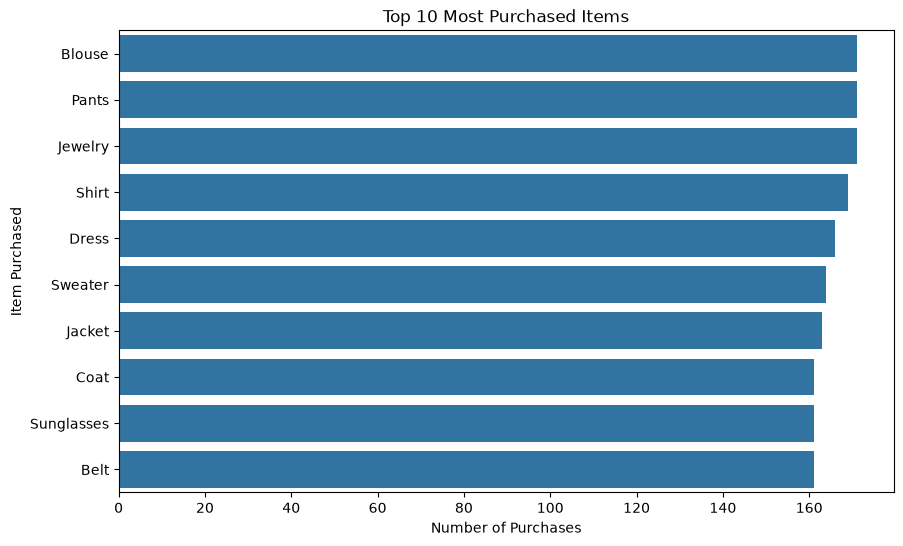

In [17]:
# TODO: plot a horizontal bar chart of the top 10 items with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
#     legend=?
# )
# plt.title?
# plt.xlabel?
# plt.ylabel?
# plt.show()
plt.figure(figsize=(10, 6))

sns.barplot(
    data=all_top_items.head(10),
    x='count',
    y='Item Purchased',
    legend=False
)

plt.title('Top 10 Most Purchased Items')
plt.xlabel('Number of Purchases')
plt.ylabel('Item Purchased')
plt.show()

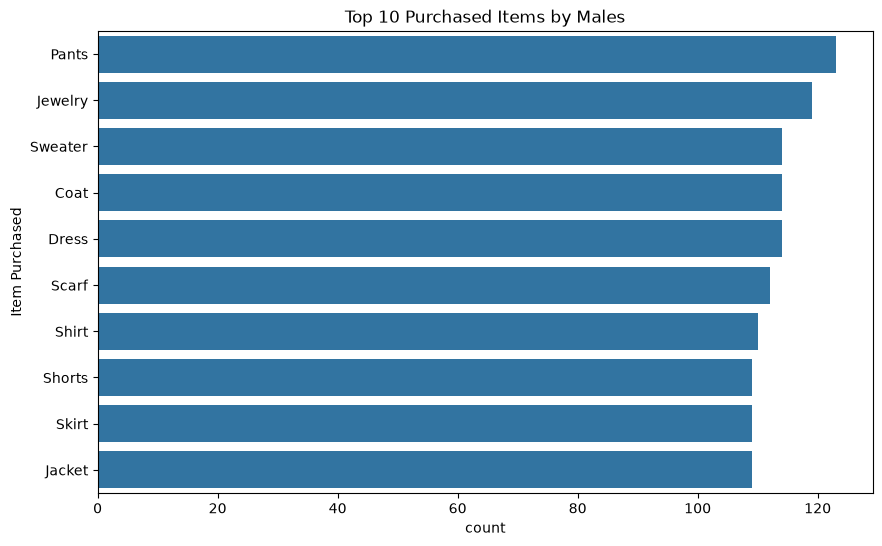

In [18]:
# TODO: plot a horizontal bar chart of the top 10 items for males with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     ?
# )
# plt.title("Top 10 Purchased Items by Males")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()
plt.figure(figsize=(10, 6))

sns.barplot(
    data=male_top_items.head(10),
    x='count',
    y='Item Purchased'
)

plt.title("Top 10 Purchased Items by Males")
plt.xlabel('count')
plt.ylabel('Item Purchased')
plt.show()

In [ ]:
# TODO: plot a horizontal bar chart of the top 10 items for females with sns.barplot()
# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=top_item_f.head(10),
#     y='Item Purchased',
#     x='count',
#     hue='Item Purchased',
#     dodge=False,
#     legend=False
# )
# plt.title("Top 10 Purchased Items by Females")
# plt.xlabel('count')
# plt.ylabel('Item Purchased')
# plt.show()

In [19]:
# TODO: count Size with value_counts() for all customers
size_counts = df['Size'].value_counts()

print(size_counts)

Size
M     1755
L     1053
S      663
XL     429
Name: count, dtype: int64


In [20]:
# TODO: count Size with value_counts() for male_df and female_df
male_size_counts = male_df['Size'].value_counts()
female_size_counts = female_df['Size'].value_counts()

print(male_size_counts)
print(female_size_counts)

Size
M     1165
L      716
S      476
XL     295
Name: count, dtype: int64
Size
M     590
L     337
S     187
XL    134
Name: count, dtype: int64


### **Category**

In [21]:
# TODO: count Category with value_counts().reset_index() for all customers
# ctg = ?
ctg = df['Category'].value_counts().reset_index()

print(ctg)

      Category  count
0     Clothing   1737
1  Accessories   1240
2     Footwear    599
3    Outerwear    324


In [22]:
# TODO: count Category with value_counts().reset_index() for male_df and female_df

male_ctg = male_df['Category'].value_counts().reset_index()
female_ctg = female_df['Category'].value_counts().reset_index()

print(male_ctg)
print(female_ctg)

      Category  count
0     Clothing   1181
1  Accessories    848
2     Footwear    400
3    Outerwear    223
      Category  count
0     Clothing    556
1  Accessories    392
2     Footwear    199
3    Outerwear    101


In [57]:
# TODO: plot a bar chart of preferred Category for males with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     ?
# )
# plt.title("Preferred Category by Males")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()

In [58]:
# TODO: plot a bar chart of preferred Category for females with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.xlabel('Category')
# plt.ylabel('count')
# plt.show()

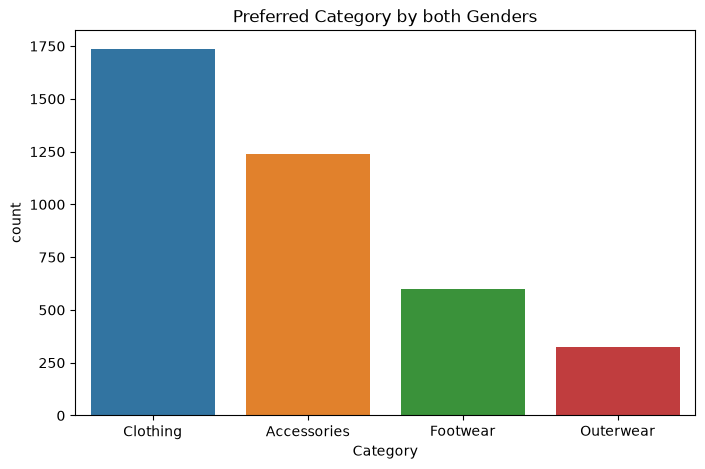

In [23]:
# TODO: plot a bar chart of preferred Category for both genders with sns.barplot()
# plt.figure(figsize=(8, 5))
# sns.barplot(
#     data=ctg,
#     x='Category',
#     y='count',
#     hue='Category',
#     dodge=False,
#     legend=False
# )
# plt.title("Preferred Category by both Genders")
# plt.show()


plt.figure(figsize=(8, 5))
sns.barplot(
data=ctg,
x='Category',
y='count',
hue='Category',
dodge=False,
legend=False
)
plt.title("Preferred Category by both Genders")
plt.show()


In [60]:
# TODO: create waffle_data_m and waffle_data_f from Category value_counts()
# waffle_data_m = dict(male_df['Category'].value_counts())
# waffle_data_f = dict(female_df['Category'].value_counts())


# TODO: create waffle_data_f from female_df['Category'].value_counts()


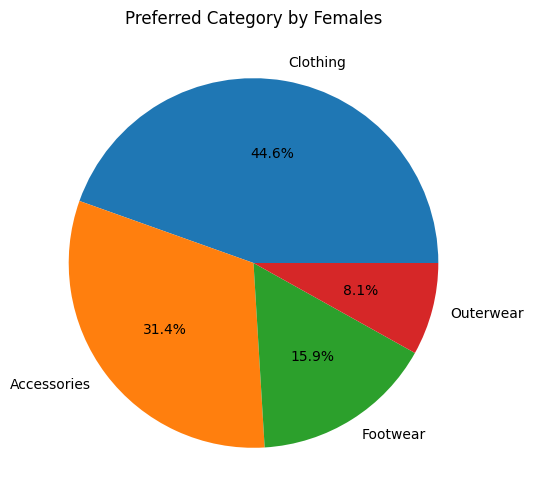

In [ ]:
# TODO: plot a pie chart of preferred Category for females with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#    ?
# )
# plt.title("Preferred Category by Females")
# plt.show()

In [62]:
# TODO: plot a pie chart of preferred Category for males with plt.pie()
# plt.figure(figsize=(6, 6))
# plt.pie(
#     waffle_data_m.values(),
#     labels=waffle_data_m.keys(),
#     autopct='%1.1f%%'
# )
# plt.title("Preferred Category by Males")
# plt.show() 

### **Review ratings**

In [ ]:
# TODO: filter female Clothing rows, then mean of Review Rating
# cr_f = ?
# avg_cr_f = ?

In [ ]:
# TODO: filter male Clothing rows, then mean of Review Rating
# cr_m = ?
# avg_cr_m = ?

In [ ]:
# avg_cr_m,avg_cr_f

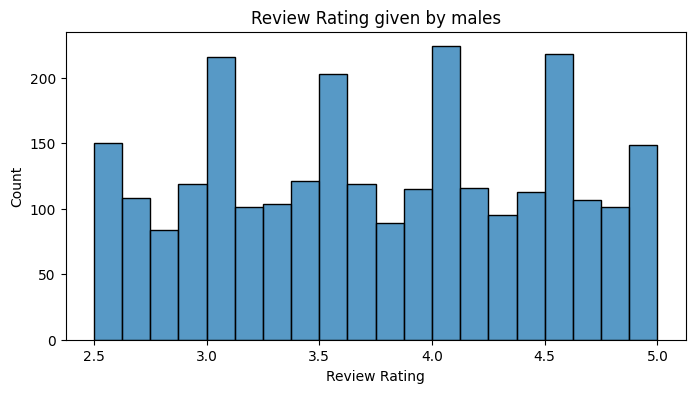

In [73]:
# TODO: plot Review Rating histograms for males and females with sns.histplot()
# males
plt.figure(figsize=(8, 4))
sns.histplot(data=male_df, x='Review Rating', bins=20)
plt.title("Review Rating given by males")
plt.show()

# females
# ?

In [65]:
# TODO: count Review Rating with value_counts() for male Clothing (cr_m)


### **Purchase Amount (USD)**

In [ ]:
# TODO: sum Purchase Amount (USD) for males
# m_tpa = ?

# # TODO: sum Purchase Amount (USD) for females
# f_tpa =?

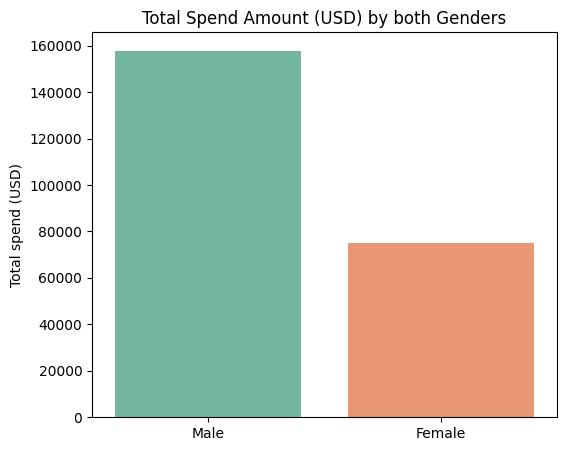

In [ ]:
# TODO: plot total spend by gender with sns.barplot()
# plt.figure(figsize=(6, 5))
# sns.barplot(
#     ?
# )
# plt.title("Total Spend Amount (USD) by both Genders")
# plt.ylabel('Total spend (USD)')
# plt.show()

In [69]:
# TODO: filter female_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_f = cr_f
# ca_f = female_df[female_df['Category']=='Accessories']
# cf_f = ?
# co_f = ?

In [ ]:
# TODO: filter male_df by Category: Clothing, Accessories, Footwear, Outerwear
# cc_m = cr_m
# ca_m = ?
# cf_m = ?
# co_m = ?

In [72]:
# TODO: create pcu dict from Promo Code Used value_counts()


### **Relationships (multivariate)**

Numeric columns only: Age, Purchase Amount (USD), Review Rating, Previous Purchases.

In [74]:
# TODO: compute correlation with df.corr(numeric_only=True), then plot a heatmap with sns.heatmap()


### **Feature engineering**

Dummy variables for columns with few levels. Scale numeric columns (keep originals). Bin purchase amount.

In [ ]:
# TODO: dummy variables for Gender, Size, and Category with pd.get_dummies()
# df = pd.get_dummies(df, columns=[?], dtype=?)
# df.head()

In [ ]:
# TODO: use MinMaxScaler on Purchase Amount (USD) and StandardScaler on Age (keep original columns)
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# df['Amount_minmax'] = ?
# df['Age_standard'] = ?
# df[['Purchase Amount (USD)', 'Amount_minmax', 'Age', 'Age_standard']].head()

In [ ]:
# TODO: use pd.cut() to bin Purchase Amount (USD) into Low / Medium / High
# df['Amount_bin'] = ?
# df['Amount_bin'].value_counts()

### **Summary**

Write 4–5 insights from the plots. These are associations, not causal claims.

Examples to check:
- Which items and categories are most common for males vs females?
- Do males and females spend a similar total amount?
- Is Review Rating similar across genders?
- How often is a promo code used?

# TODO: write insights
- 
- 
- 
- 

Caveat: correlation is not causation.